# Лабораторная работа 2 — Кредитный скоринг (Kaggle MAI ML Lab 2 FIIT 2025)


## 0. Импорт библиотек и загрузка данных

На этом шаге:
- подключаем необходимые библиотеки для анализа и визуализации,
- загружаем файлы `train_c.csv` и `test_c.csv`,
- смотрим размеры таблиц и структуру признаков,
- проверяем распределение целевой переменной `LoanApproved` в train.

In [67]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
pd.set_option("display.max_columns", None)

train_path = "train_c.csv"
test_path = "test_c.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Размер train:", train.shape)
print("Размер test:", test.shape)

print("\nПервые строки train:")
display(train.head())

print("\nПервые строки test:")
display(test.head())

print("\nТипы столбцов train:")
print(train.dtypes)

if "LoanApproved" in train.columns:
    print("\nРаспределение LoanApproved (включая NaN):")
    print(train["LoanApproved"].value_counts(dropna=False))
else:
    print("\nВ train нет столбца 'LoanApproved' — проверьте структуру файла.")

if "LoanApproved" in train.columns:
    train_labeled = train[train["LoanApproved"].notna()].copy()
    train_labeled["LoanApproved"] = train_labeled["LoanApproved"].astype(int)
    print("\nРазмер train_labeled (строки с известным LoanApproved):", train_labeled.shape)


Размер train: (11017, 35)
Размер test: (5000, 35)

Первые строки train:


,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,0.151985,2.0,1.0,0.168542,0.0,Education,0.0,23.0,5.0,2539.0,247.0,50072.0,15005.0,5569.083333,0.908289,4.0,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,0.0
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,0.175693,3.0,0.0,0.141553,0.0,Home,0.0,27.0,11.0,844.0,694.0,91878.0,64877.0,14345.583333,0.797339,2.0,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,1.0
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,0.444605,3.0,0.0,0.030987,1.0,Education,0.0,21.0,12.0,12756.0,651.0,292300.0,13918.0,25000.000000,0.915945,3.0,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,1.0
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,0.188452,7.0,0.0,0.379843,0.0,Debt Consolidation,0.0,27.0,21.0,1524.0,529.0,13070.0,3846.0,2890.250000,0.876416,3.0,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,1.0
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,0.273431,3.0,1.0,0.068659,0.0,Debt Consolidation,0.0,35.0,9.0,1973.0,128.0,33357.0,351603.0,25000.000000,0.888689,5.0,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,1.0



Первые строки test:


,ID,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio
0,0,1979-01-03,49,207095,850,14458,60,Single,0,Rent,376,0.077124,2,0,0.438186,0,Auto,0,28,15,5008,619,5627,25585,17257.916667,0.883232,6,Employed,High School,23,10626,0.104458,0.125350,325.532336,0.040650
1,1,2006-04-10,28,64653,674,65491,48,Single,2,Own,238,0.073977,4,2,0.446233,0,Education,0,23,28,4590,710,317306,18282,5387.750000,0.791928,3,Employed,High School,3,299024,0.233491,0.260561,2210.247757,0.454410
2,2,2013-11-28,41,300000,768,16811,60,Single,1,Own,469,0.331499,5,0,0.035313,0,Auto,0,23,9,2429,623,13115,6136,25000.000000,0.805826,3,Employed,High School,19,6979,0.147811,0.154571,403.977431,0.034919
3,3,1995-08-24,50,300000,850,48737,36,Divorced,0,Mortgage,567,0.544696,2,1,0.278922,0,Education,0,24,9,14571,10749,25320,93806,25000.000000,0.829294,3,Self-Employed,Bachelor,26,8438,0.118737,0.099712,1571.946906,0.085558
4,4,1980-06-15,35,300000,672,51916,60,Single,6,Mortgage,106,0.436103,0,0,0.196376,0,Home,0,14,6,930,2926,439068,2852,25000.000000,0.735013,7,Employed,Associate,12,436216,0.230916,0.237727,1486.675235,0.063707



Типы столбцов train:
ApplicationDate                object
Age                           float64
AnnualIncome                  float64
CreditScore                   float64
LoanAmount                    float64
LoanDuration                  float64
MaritalStatus                  object
NumberOfDependents            float64
HomeOwnershipStatus            object
MonthlyDebtPayments           float64
CreditCardUtilizationRate     float64
NumberOfOpenCreditLines       float64
NumberOfCreditInquiries       float64
DebtToIncomeRatio             float64
BankruptcyHistory             float64
LoanPurpose                    object
PreviousLoanDefaults          float64
PaymentHistory                float64
LengthOfCreditHistory         float64
SavingsAccountBalance         float64
CheckingAccountBalance        float64
TotalAssets                   float64
TotalLiabilities              float64
MonthlyIncome                 float64
UtilityBillsPaymentHistory    float64
JobTenure                   

In [68]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names, but LGBMClassifier was fitted with feature names",
    category=UserWarning
)

# они не влияют на качество вообще
# это чисто болтовня sklearn + LightGBM из-за проверки имён фич

## 1. Разведочный анализ данных (EDA)

В этом разделе:
- анализируем распределение целевой переменной `LoanApproved`;
- смотрим динамику заявок и одобрений по годам;
- исследуем распределения ключевых числовых признаков;
- анализируем зависимости признаков от целевой переменной;
- строим матрицу корреляций числовых признаков;
- формируем первые выводы для последующей предобработки и моделирования.


In [69]:
eda_df = train_labeled.copy()

# ApplicationDate в формат datetime
eda_df["ApplicationDate"] = pd.to_datetime(eda_df["ApplicationDate"], errors="coerce")

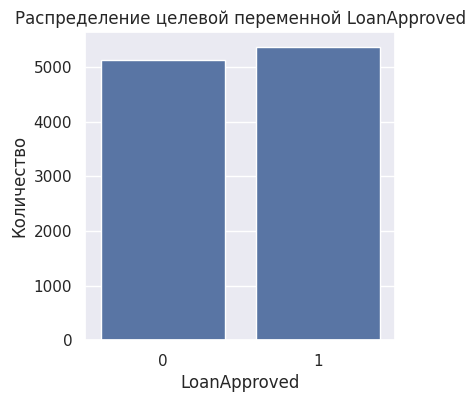

Доли классов LoanApproved:
LoanApproved
1    0.511776
0    0.488224
Name: proportion, dtype: float64


In [70]:
# 1. Баланс классов LoanApproved

plt.figure(figsize=(4, 4))
sns.countplot(x="LoanApproved", data=eda_df)
plt.title("Распределение целевой переменной LoanApproved")
plt.xlabel("LoanApproved")
plt.ylabel("Количество")
plt.show()

print("Доли классов LoanApproved:")
print(eda_df["LoanApproved"].value_counts(normalize=True))

**Вывод** 

Распределение целевой переменной `LoanApproved` близко к равномерному: число одобренных заявок (класс 1) и отклонённых заявок (класс 0) примерно одинаково. Существенного дисбаланса классов нет, поэтому можно использовать стандартное разбиение `train_test_split` с `stratify=y` без дополнительных методов балансировки выборки.



Статистика по годам заявки:


,ApplicationYear,n_applications,approval_rate
0,1979,256,0.480469
1,1980,267,0.539326
2,1981,263,0.539924
3,1982,260,0.561538
4,1983,259,0.544402
5,1984,248,0.524194
6,1985,259,0.501931
7,1986,254,0.500000
8,1987,267,0.505618
9,1988,258,0.507752


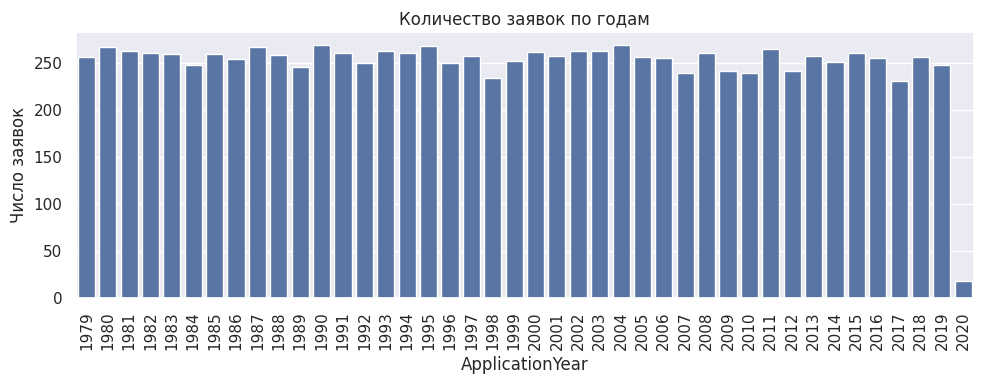

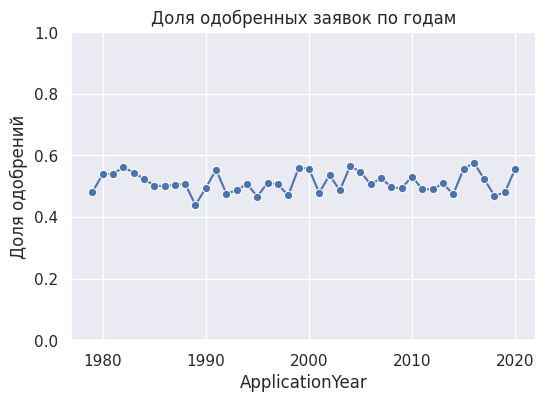

In [71]:
# 2. Динамика заявок и одобрений по годам заявки

eda_df["ApplicationYear"] = eda_df["ApplicationDate"].dt.year

year_stats = (
    eda_df
    .groupby("ApplicationYear")["LoanApproved"]
    .agg(["count", "mean"])
    .reset_index()
    .rename(columns={"count": "n_applications", "mean": "approval_rate"})
)

print("\nСтатистика по годам заявки:")
display(year_stats)

plt.figure(figsize=(10, 4))
year_stats_sorted = year_stats.sort_values("ApplicationYear").copy()
year_stats_sorted["ApplicationYear"] = year_stats_sorted["ApplicationYear"].astype(int)

sns.barplot(
    x="ApplicationYear",
    y="n_applications",
    data=year_stats_sorted
)

plt.title("Количество заявок по годам")
plt.ylabel("Число заявок")
plt.xlabel("ApplicationYear")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 4))
sns.lineplot(x="ApplicationYear", y="approval_rate", data=year_stats, marker="o")
plt.title("Доля одобренных заявок по годам")
plt.ylabel("Доля одобрений")
plt.ylim(0, 1)
plt.show()

**Вывод** 

Количество заявок по годам примерно одинаково (около 230–270 в год) за период 1979–2019. В 2020 году наблюдается резкое снижение числа заявок, что, вероятнее всего, связано с тем, что данные за этот год представлены не полностью (обрезка периода наблюдений). В целом распределение по годам выглядит стабильным и не указывает на явные проблемы с данными.

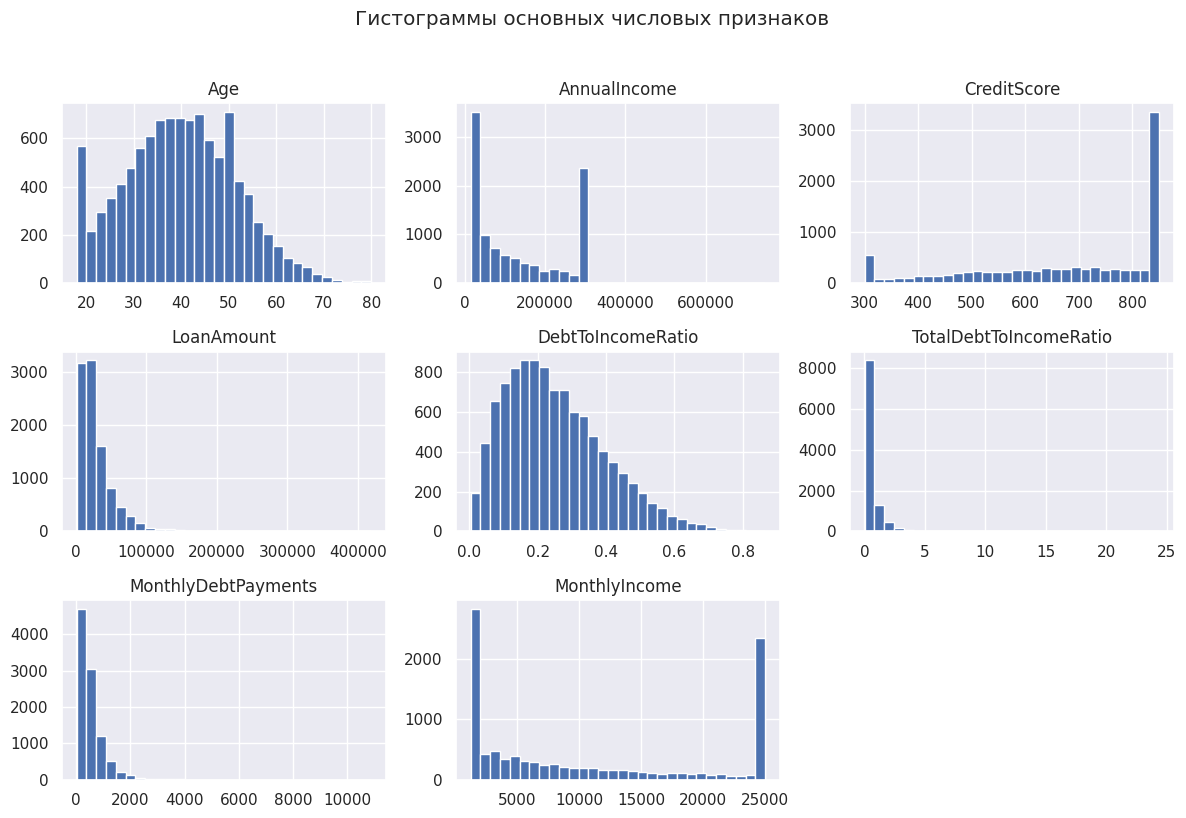

In [72]:
# 3. Распределения основных числовых признаков

numeric_cols_for_hist = [
    "Age",
    "AnnualIncome",
    "CreditScore",
    "LoanAmount",
    "DebtToIncomeRatio",
    "TotalDebtToIncomeRatio",
    "MonthlyDebtPayments",
    "MonthlyIncome"
]

existing_numeric_cols = [col for col in numeric_cols_for_hist if col in eda_df.columns]

eda_df[existing_numeric_cols].hist(bins=30, figsize=(12, 8))
plt.suptitle("Гистограммы основных числовых признаков", y=1.02)
plt.tight_layout()
plt.show()

**Вывод** 

Большинство числовых финансовых признаков (доходы, суммы кредитов, платежи, долговые нагрузки) имеют правосторонние распределения с длинными хвостами: в данных много клиентов с небольшими суммами и редкие крупные значения. Показатель `TotalDebtToIncomeRatio` содержит заметные выбросы (очень большие значения), что стоит учитывать при обучении линейных моделей (при необходимости можно применить лог-преобразование или обрезку выбросов). Возраст и отношение долга к доходу (`DebtToIncomeRatio`) распределены более аккуратно, без сильных выбросов.

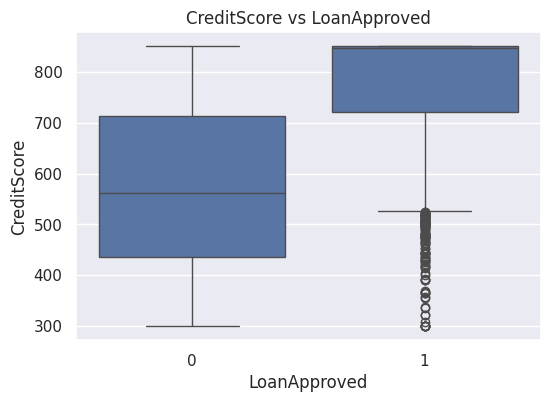

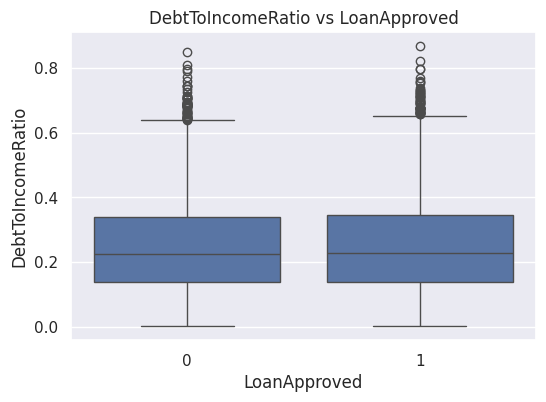

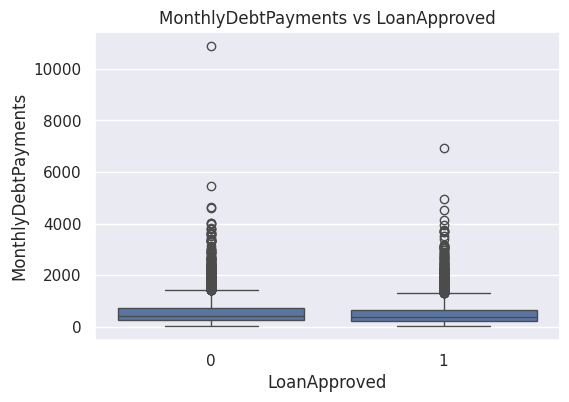

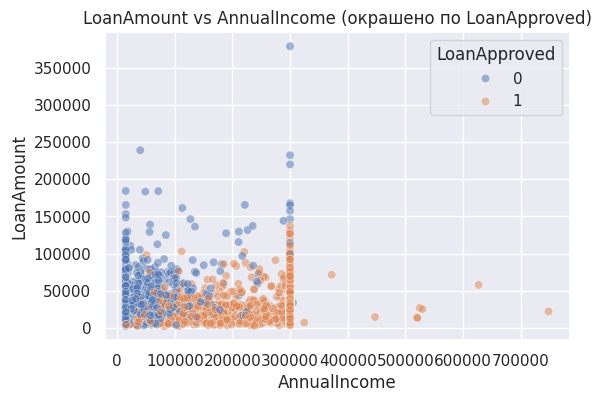

In [73]:
# 4. Зависимость некоторых признаков от LoanApproved

plt.figure(figsize=(6, 4))
sns.boxplot(x="LoanApproved", y="CreditScore", data=eda_df)
plt.title("CreditScore vs LoanApproved")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x="LoanApproved", y="DebtToIncomeRatio", data=eda_df)
plt.title("DebtToIncomeRatio vs LoanApproved")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x="LoanApproved", y="MonthlyDebtPayments", data=eda_df)
plt.title("MonthlyDebtPayments vs LoanApproved")
plt.show()

# пример зависимости между признаками с окраской по таргету
sample_size = min(2000, eda_df.shape[0])
eda_sample = eda_df.sample(sample_size, random_state=42)

plt.figure(figsize=(6, 4))
sns.scatterplot(
    x="AnnualIncome",
    y="LoanAmount",
    hue="LoanApproved",
    data=eda_sample,
    alpha=0.5
)
plt.title("LoanAmount vs AnnualIncome (окрашено по LoanApproved)")
plt.show()

**Вывод**

- `CreditScore` демонстрирует сильное разделение классов: у одобренных заявок кредитный рейтинг существенно выше, чем у отклонённых, распределения мало пересекаются. Это один из ключевых признаков модели.
- `DebtToIncomeRatio` и `MonthlyDebtPayments` по отдельности не дают чёткого разделения между классами: их распределения для `LoanApproved = 0` и `LoanApproved = 1` очень похожи и содержат много выбросов. Эти признаки будут полезнее в комбинации с другими (доход, сумма кредита).
- На диаграмме рассеяния `LoanAmount` vs `AnnualIncome` видно, что большие кредиты чаще берут клиенты с высоким доходом, а при низком доходе крупные суммы чаще приводят к отказу. Это подтверждает важность совместного анализа дохода и суммы кредита и мотивирует использование нелинейных моделей (деревья, бустинги) и/или составных признаков.



MaritalStatus и LoanApproved:


,MaritalStatus,n,approval_rate
0,Divorced,1562,0.537772
1,Married,5145,0.506706
2,Single,3217,0.505751
3,Widowed,563,0.520426


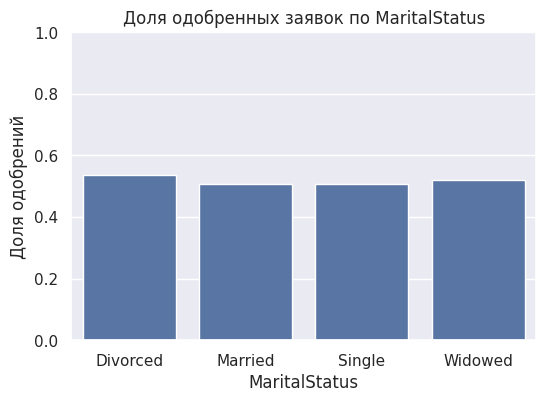

In [74]:
# 5. Пример анализа категориального признака vs таргет

if "MaritalStatus" in eda_df.columns:
    marital_stats = (
        eda_df
        .groupby("MaritalStatus")["LoanApproved"]
        .agg(["count", "mean"])
        .reset_index()
        .rename(columns={"count": "n", "mean": "approval_rate"})
    )
    print("\nMaritalStatus и LoanApproved:")
    display(marital_stats)

    plt.figure(figsize=(6, 4))
    sns.barplot(x="MaritalStatus", y="approval_rate", data=marital_stats)
    plt.title("Доля одобренных заявок по MaritalStatus")
    plt.ylabel("Доля одобрений")
    plt.ylim(0, 1)
    plt.show()


**Вывод** 

Доля одобренных заявок слабо зависит от семейного положения: для всех категорий `MaritalStatus` она находится около 0.5, лишь незначительно выше у `Divorced` и `Widowed`. Значит, сам по себе этот признак обладает небольшой предсказательной силой, но его имеет смысл оставить в модели как категориальный для учёта возможных взаимодействий с другими признаками.


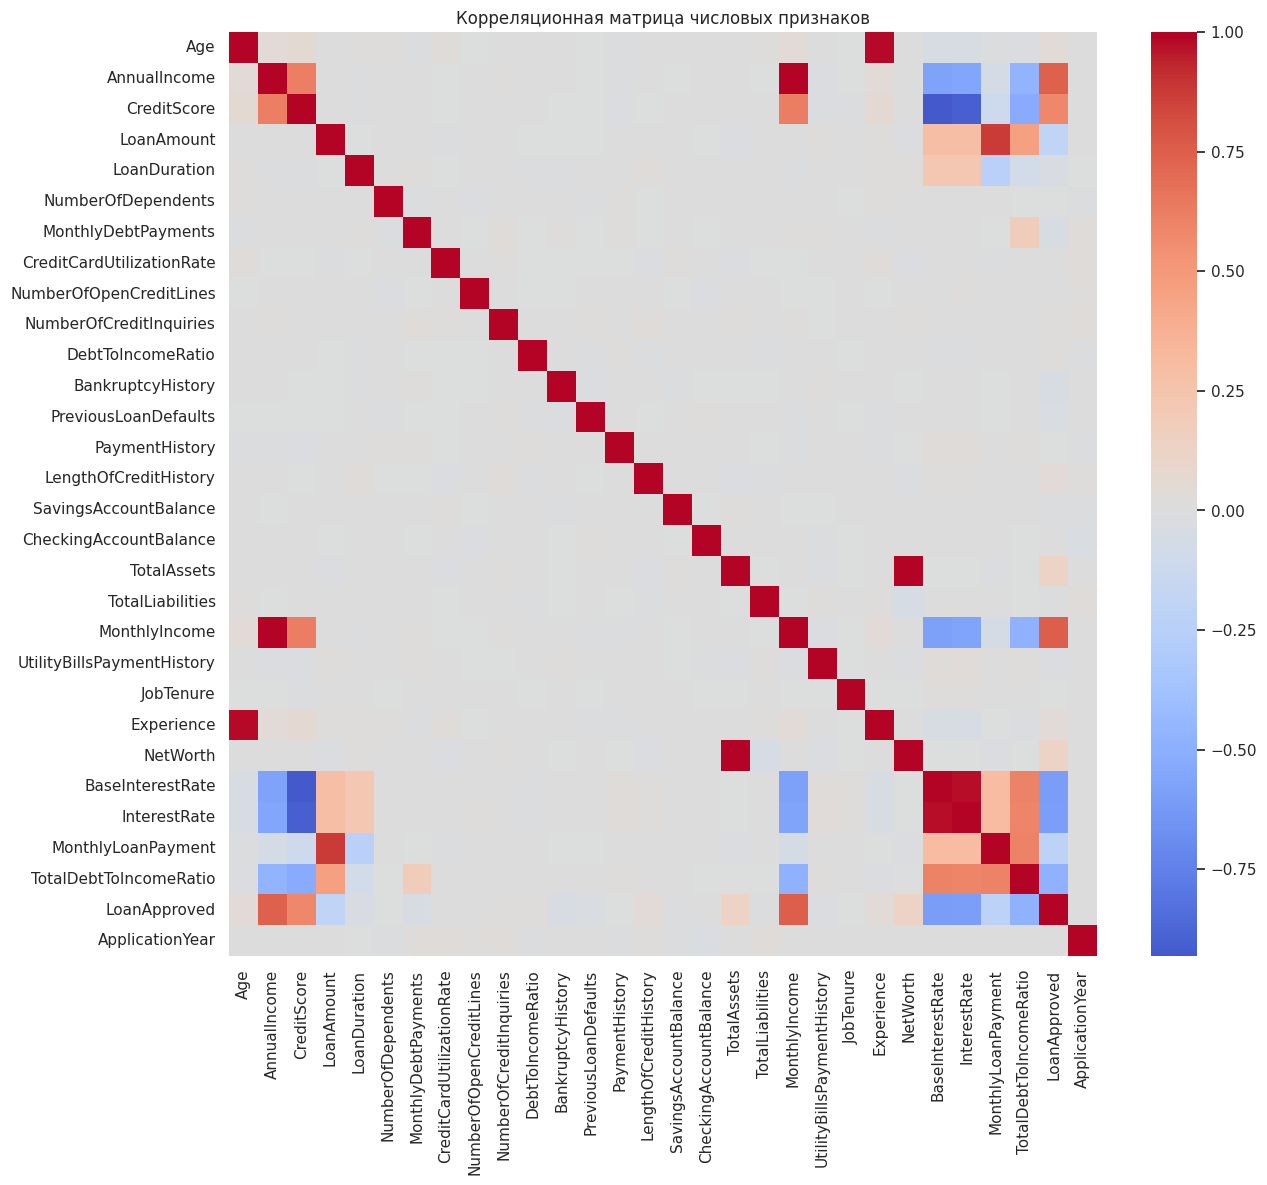

In [75]:
# 6. Корреляционная матрица числовых фичей

numeric_cols_all = eda_df.select_dtypes(include=[np.number]).columns.tolist()

corr_matrix = eda_df[numeric_cols_all].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Корреляционная матрица числовых признаков")
plt.show()

**Вывод** 

Корреляционная матрица показывает несколько групп сильно связанных признаков: годовой и месячный доход (`AnnualIncome`, `MonthlyIncome`), активы и обязательства (`TotalAssets`, `TotalLiabilities`, `NetWorth`), а также параметры кредита (`LoanAmount`, `MonthlyLoanPayment`, `TotalDebtToIncomeRatio`). Это указывает на наличие мультиколлинеарности, что важно учитывать при использовании линейных моделей. Наиболее заметную положительную корреляцию с целевой переменной `LoanApproved` имеют `CreditScore`, показатели платёжной дисциплины и длительность кредитной истории, а отрицательную — наличие предыдущих дефолтов и банкротств. Эти признаки ожидаемо будут среди наиболее информативных для модели.


## 2. Подготовка данных для моделей

На этом шаге:

1. Преобразуем `ApplicationDate` в числовые признаки:
   - `ApplicationYear`,
   - `ApplicationMonth`,
   - `ApplicationDayOfWeek`.
   Исходный столбец даты удаляем.

2. Выделяем строки с известной целевой переменной `LoanApproved`
   и формируем матрицу признаков `X` и вектор ответов `y`.

3. Делим данные на обучающую и валидационную выборки (`train_test_split` с `stratify=y`).

4. Определяем числовые и категориальные признаки и создаём общий препроцессор:
   - числовые признаки: заполнение пропусков медианой (`SimpleImputer(strategy="median")`);
   - категориальные признаки: заполнение модой + one-hot-encoding
     (`SimpleImputer(strategy="most_frequent")` + `OneHotEncoder(handle_unknown="ignore")`).

Этот препроцессор далее будем использовать во всех моделях (baseline, bagging, бустинг и т.д.).


In [76]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# преобразует ApplicationDate в три числовых признака:
# ApplicationYear
# ApplicationMonth
# ApplicationDayOfWeek
# исходный столбец ApplicationDate удаляется
def add_date_features(df):
    result = df.copy()
    result["ApplicationDate"] = pd.to_datetime(result["ApplicationDate"], errors="coerce")

    result["ApplicationYear"] = result["ApplicationDate"].dt.year
    result["ApplicationMonth"] = result["ApplicationDate"].dt.month
    result["ApplicationDayOfWeek"] = result["ApplicationDate"].dt.dayofweek

    result = result.drop(columns=["ApplicationDate"])
    return result


train_with_dates = add_date_features(train)
test_with_dates = add_date_features(test)

# строки только с известным таргетом
train_labeled_full = train_with_dates[train_with_dates["LoanApproved"].notna()].copy()
train_labeled_full["LoanApproved"] = train_labeled_full["LoanApproved"].astype(int)

print("Размер train_labeled_full:", train_labeled_full.shape)

# формируем X и y
target_col = "LoanApproved"
y = train_labeled_full[target_col]
X = train_labeled_full.drop(columns=[target_col])

if "ID" in X.columns:
    X = X.drop(columns=["ID"])

print("Размер X:", X.shape)
print("Размер y:", y.shape)

# определяем числовые и категориальные признаки
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("\nЧисловых признаков:", len(numeric_features))
print(numeric_features)
print("\nКатегориальных признаков:", len(categorical_features))
print(categorical_features)

# разделение на train/valid
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nРазмер X_train:", X_train.shape)
print("Размер X_valid:", X_valid.shape)

# --- Общие имьютеры --- #

numeric_imputer = SimpleImputer(strategy="median")
categorical_imputer = SimpleImputer(strategy="most_frequent")

# --- Трансформеры --- #

# 1) Для деревьев / леса / бэггинга (sparse one-hot, без скейлера)
numeric_transformer_tree = Pipeline(
    steps=[
        ("imputer", numeric_imputer)
    ]
)

categorical_transformer_tree = Pipeline(
    steps=[
        ("imputer", categorical_imputer),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_features),
        ("cat", categorical_transformer_tree, categorical_features)
    ]
)

# 2) Для логистической регрессии (импутация + StandardScaler + sparse one-hot)
numeric_transformer_logreg = Pipeline(
    steps=[
        ("imputer", numeric_imputer),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer_logreg = Pipeline(
    steps=[
        ("imputer", categorical_imputer),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor_logreg = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_logreg, numeric_features),
        ("cat", categorical_transformer_logreg, categorical_features)
    ]
)

# 3) Для градиентных бустингов (импутация, без скейлера, dense one-hot)
numeric_transformer_gb = Pipeline(
    steps=[
        ("imputer", numeric_imputer)
    ]
)

categorical_transformer_gb = Pipeline(
    steps=[
        ("imputer", categorical_imputer),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor_gb = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_gb, numeric_features),
        ("cat", categorical_transformer_gb, categorical_features)
    ]
)

#preprocessor_tree, preprocessor_logreg, preprocessor_gb

Размер train_labeled_full: (10487, 37)
Размер X: (10487, 36)
Размер y: (10487,)

Числовых признаков: 31
['Age', 'AnnualIncome', 'CreditScore', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'Experience', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'ApplicationYear', 'ApplicationMonth', 'ApplicationDayOfWeek']

Категориальных признаков: 5
['MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'EmploymentStatus', 'EducationLevel']

Размер X_train: (8389, 36)
Размер X_valid: (2098, 36)


## 3. Собственные реализации метрик качества

В этом разделе реализуем основные метрики бинарной классификации:

- Accuracy
- Precision
- Recall
- F1-score

А также дополнительные метрики:

- ROC-AUC
- PR-AUC (Average Precision)

Далее сравним результаты с реализациями из `sklearn.metrics` на искусственных данных, 
чтобы убедиться, что формулы реализованы корректно.


In [77]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Accuracy = (TP + TN) / (TP + TN + FP + FN)
def accuracy_score_custom(y_true, y_pred):
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)

    n_samples = y_true_array.shape[0]
    if n_samples == 0:
        return 0.0

    correct = np.sum(y_true_array == y_pred_array)
    value = float(correct) / float(n_samples)
    return value

# Precision = TP / (TP + FP)
def precision_score_custom(y_true, y_pred, positive_label=1):
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)

    tp = np.sum((y_true_array == positive_label) & (y_pred_array == positive_label))
    fp = np.sum((y_true_array != positive_label) & (y_pred_array == positive_label))

    if tp + fp == 0:
        return 0.0

    value = float(tp) / float(tp + fp)
    return value

# Recall = TP / (TP + FN)
def recall_score_custom(y_true, y_pred, positive_label=1):
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)

    tp = np.sum((y_true_array == positive_label) & (y_pred_array == positive_label))
    fn = np.sum((y_true_array == positive_label) & (y_pred_array != positive_label))

    if tp + fn == 0:
        return 0.0

    value = float(tp) / float(tp + fn)
    return value

# F1 = 2 * Precision * Recall / (Precision + Recall)
def f1_score_custom(y_true, y_pred, positive_label=1):
    precision_value = precision_score_custom(y_true, y_pred, positive_label)
    recall_value = recall_score_custom(y_true, y_pred, positive_label)

    if precision_value + recall_value == 0.0:
        return 0.0

    value = 2.0 * precision_value * recall_value / float(precision_value + recall_value)
    return value

# приближение ROC-AUC через явное построение ROC-кривой и численное интегрирование
def roc_auc_score_custom(y_true, y_score):
    y_true_array = np.asarray(y_true)
    y_score_array = np.asarray(y_score)

    # только валидные наблюдения с метками 0 или 1
    mask_pos = y_true_array == 1
    mask_neg = y_true_array == 0
    pos_count = np.sum(mask_pos)
    neg_count = np.sum(mask_neg)

    if pos_count == 0 or neg_count == 0:
        return 0.0

    # cортируем по score по возрастанию
    order = np.argsort(y_score_array)
    y_true_sorted = y_true_array[order]
    y_score_sorted = y_score_array[order]

    tpr_values = [0.0]
    fpr_values = [0.0]

    tp = 0.0
    fp = 0.0
    last_score = None

    for i in range(y_true_sorted.shape[0] - 1, -1, -1):
        score = y_score_sorted[i]
        label = y_true_sorted[i]

        if last_score is None or score != last_score:
            tpr_values.append(tp / float(pos_count))
            fpr_values.append(fp / float(neg_count))
            last_score = score

        if label == 1:
            tp = tp + 1.0
        else:
            fp = fp + 1.0

    tpr_values.append(1.0)
    fpr_values.append(1.0)

    # площадь под кривой методом трапеций
    auc = 0.0
    for i in range(1, len(tpr_values)):
        delta_fpr = fpr_values[i] - fpr_values[i - 1]
        avg_tpr = (tpr_values[i] + tpr_values[i - 1]) / 2.0
        auc = auc + delta_fpr * avg_tpr

    return auc

# AP = sum_k (precision_k * (recall_k - recall_{k-1}))
def pr_auc_score_custom(y_true, y_score):
    y_true_array = np.asarray(y_true)
    y_score_array = np.asarray(y_score)

    mask_pos = y_true_array == 1
    pos_count = np.sum(mask_pos)
    if pos_count == 0:
        return 0.0

    # сортируем по score по убыванию
    order = np.argsort(-y_score_array)
    y_true_sorted = y_true_array[order]

    tp = 0.0
    fp = 0.0
    precisions = []
    recalls = []

    for i in range(y_true_sorted.shape[0]):
        if y_true_sorted[i] == 1:
            tp = tp + 1.0
        else:
            fp = fp + 1.0

        precision_value = tp / float(tp + fp)
        recall_value = tp / float(pos_count)

        precisions.append(precision_value)
        recalls.append(recall_value)

    precisions_array = np.asarray(precisions)
    recalls_array = np.asarray(recalls)

    auc = 0.0
    prev_recall = 0.0

    for i in range(recalls_array.shape[0]):
        delta_recall = recalls_array[i] - prev_recall
        auc = auc + precisions_array[i] * delta_recall
        prev_recall = recalls_array[i]

    return auc

In [78]:
# случайные данные для проверки метрик
rng = np.random.RandomState(0)
y_true_test = rng.randint(0, 2, size=200)
y_pred_test = rng.randint(0, 2, size=200)
y_score_test = rng.rand(200)

print("Accuracy custom / sklearn:")
print(accuracy_score_custom(y_true_test, y_pred_test),
      accuracy_score(y_true_test, y_pred_test))

print("\nPrecision custom / sklearn:")
print(precision_score_custom(y_true_test, y_pred_test),
      precision_score(y_true_test, y_pred_test))

print("\nRecall custom / sklearn:")
print(recall_score_custom(y_true_test, y_pred_test),
      recall_score(y_true_test, y_pred_test))

print("\nF1 custom / sklearn:")
print(f1_score_custom(y_true_test, y_pred_test),
      f1_score(y_true_test, y_pred_test))

print("\nROC-AUC custom / sklearn:")
print(roc_auc_score_custom(y_true_test, y_score_test),
      roc_auc_score(y_true_test, y_score_test))

print("\nPR-AUC custom / sklearn (Average Precision):")
print(pr_auc_score_custom(y_true_test, y_score_test),
      average_precision_score(y_true_test, y_score_test))


Accuracy custom / sklearn:
0.5 0.5

Precision custom / sklearn:
0.5045045045045045 0.5045045045045045

Recall custom / sklearn:
0.5544554455445545 0.5544554455445545

F1 custom / sklearn:
0.5283018867924528 0.5283018867924528

ROC-AUC custom / sklearn:
0.5869586958695868 0.586958695869587

PR-AUC custom / sklearn (Average Precision):
0.6049354625828072 0.6049354625828072


## 4. Базовые модели и функция для оценки

На этом шаге:

1. Реализуем функцию `evaluate_model`, которая:
   - обучает модель на обучающей выборке,
   - считает основные метрики (ROC-AUC, PR-AUC, Accuracy, Precision, Recall, F1)
     как по `sklearn`, так и нашими самописными функциями,
   - возвращает результаты в виде словаря.

2. Построим две простые базовые модели:
   - Logistic Regression,
   - Random Forest.

3. Оценим их качество на валидационной выборке. Эти результаты будем использовать
   как исходную «точку отсчёта» перед усложнением моделей (bagging, boosting и т.д.).


In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


def evaluate_model(model, X_train_local, X_valid_local, y_train_local, y_valid_local, model_name):
    """
    Обучает модель и возвращает словарь с основными метриками
    (как из sklearn, так и из реализованных вручную функций)

    Параметры:
        model: sklearn-модель или Pipeline
        X_train_local, y_train_local: обучающая выборка
        X_valid_local, y_valid_local: валидационная выборка
        model_name: строка с названием модели

    Возвращает:
        dict со значениями метрик
    """
    model.fit(X_train_local, y_train_local)

    y_pred = model.predict(X_valid_local)

    has_proba = hasattr(model, "predict_proba")
    y_proba = None
    if has_proba:
        y_proba = model.predict_proba(X_valid_local)[:, 1]

    # метрики sklearn
    acc = accuracy_score(y_valid_local, y_pred)
    prec = precision_score(y_valid_local, y_pred)
    rec = recall_score(y_valid_local, y_pred)
    f1 = f1_score(y_valid_local, y_pred)

    roc_auc = None
    pr_auc = None
    if y_proba is not None:
        roc_auc = roc_auc_score(y_valid_local, y_proba)
        pr_auc = average_precision_score(y_valid_local, y_proba)

    # мои метрики
    acc_custom = accuracy_score_custom(y_valid_local, y_pred)
    prec_custom = precision_score_custom(y_valid_local, y_pred)
    rec_custom = recall_score_custom(y_valid_local, y_pred)
    f1_custom = f1_score_custom(y_valid_local, y_pred)

    roc_auc_custom_value = None
    pr_auc_custom_value = None
    if y_proba is not None:
        roc_auc_custom_value = roc_auc_score_custom(y_valid_local, y_proba)
        pr_auc_custom_value = pr_auc_score_custom(y_valid_local, y_proba)

    metrics = {
        "model": model_name,
        "ROC_AUC_sklearn": roc_auc,
        "ROC_AUC_custom": roc_auc_custom_value,
        "PR_AUC_sklearn": pr_auc,
        "PR_AUC_custom": pr_auc_custom_value,
        "Accuracy_sklearn": acc,
        "Accuracy_custom": acc_custom,
        "Precision_sklearn": prec,
        "Precision_custom": prec_custom,
        "Recall_sklearn": rec,
        "Recall_custom": rec_custom,
        "F1_sklearn": f1,
        "F1_custom": f1_custom
    }

    return metrics

# logistic regression

log_reg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_logreg),
        ("model", LogisticRegression(
            max_iter=5000,
            solver="lbfgs",  
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# random forest

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

baseline_results = []

baseline_results.append(
    evaluate_model(
        log_reg_pipeline,
        X_train,
        X_valid,
        y_train,
        y_valid,
        "LogisticRegression"
    )
)

baseline_results.append(
    evaluate_model(
        rf_pipeline,
        X_train,
        X_valid,
        y_train,
        y_valid,
        "RandomForest"
    )
)

baseline_df = pd.DataFrame(baseline_results)
baseline_df

,model,ROC_AUC_sklearn,ROC_AUC_custom,PR_AUC_sklearn,PR_AUC_custom,Accuracy_sklearn,Accuracy_custom,Precision_sklearn,Precision_custom,Recall_sklearn,Recall_custom,F1_sklearn,F1_custom
0,LogisticRegression,0.981929,0.981929,0.983979,0.983979,0.927073,0.927073,0.933208,0.933208,0.923650,0.923650,0.928404,0.928404
1,RandomForest,0.980789,0.980789,0.982344,0.982467,0.924690,0.924690,0.925651,0.925651,0.927374,0.927374,0.926512,0.926512


## 5. Реализация собственного Bagging

В этом разделе:

1. Реализуем класс `CustomBaggingClassifier`:
   - в методе `fit` обучаем `n_estimators` копий базовой модели на бутстрап-выборках;
   - в методе `predict_proba` усредняем предсказанные вероятности всех базовых моделей;
   - в методе `predict` применяем порог 0.5 к средним вероятностям.

2. Сравним качество нашего бэггинга с `BaggingClassifier` из `sklearn`:
   - используем одинаковый базовый алгоритм (дерево решений),
   - одинаковое число базовых моделей и `random_state`,
   - оцениваем по метрикам ROC-AUC, PR-AUC, Accuracy, Precision, Recall, F1.


In [80]:
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Идея:
# - обучаем несколько независимых базовых моделей на бутстрап-выборках обучающей выборки
# - при предсказании усредняем вероятности всех базовых моделей
class CustomBaggingClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, base_estimator=None, n_estimators=10, random_state=None):
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.random_state = random_state

    def fit(self, X_local, y_local):
        if self.base_estimator is None:
            raise ValueError("Параметр base_estimator должен быть задан перед fit().")

        y_array = np.asarray(y_local)
        n_samples = X_local.shape[0]

        rng = np.random.RandomState(self.random_state)
        self.estimators_ = []

        for i in range(self.n_estimators):
            indices = rng.randint(0, n_samples, size=n_samples)

            estimator = clone(self.base_estimator)
            estimator.fit(X_local[indices], y_array[indices])

            self.estimators_.append(estimator)

        return self

    def predict_proba(self, X_local):
        if not hasattr(self, "estimators_"):
            raise ValueError("Модель ещё не обучена. Вызовите fit() перед predict_proba().")

        proba_sum = None

        for estimator in self.estimators_:
            proba = estimator.predict_proba(X_local)

            if proba_sum is None:
                proba_sum = proba
            else:
                proba_sum = proba_sum + proba

        avg_proba = proba_sum / float(len(self.estimators_))
        return avg_proba

    def predict(self, X_local):
        proba = self.predict_proba(X_local)
        positive_proba = proba[:, 1]
        classes = (positive_proba >= 0.5).astype(int)
        return classes


# базовое дерево решений для бэггинга
base_tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# мой бэггинг + общий препроцессор
custom_bagging_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("model", CustomBaggingClassifier(
            base_estimator=base_tree,
            n_estimators=30,
            random_state=42
        ))
    ]
)

# бэггинг из sklearn с тем же базовым деревом
sklearn_bagging_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("model", BaggingClassifier(
            estimator=DecisionTreeClassifier(
                max_depth=4,
                random_state=42
            ),
            n_estimators=30,
            bootstrap=True,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

bagging_results = []

bagging_results.append(
    evaluate_model(
        custom_bagging_pipeline,
        X_train,
        X_valid,
        y_train,
        y_valid,
        "CustomBagging(DecisionTree)"
    )
)

bagging_results.append(
    evaluate_model(
        sklearn_bagging_pipeline,
        X_train,
        X_valid,
        y_train,
        y_valid,
        "SklearnBagging(DecisionTree)"
    )
)

bagging_df = pd.DataFrame(bagging_results)
bagging_df

,model,ROC_AUC_sklearn,ROC_AUC_custom,PR_AUC_sklearn,PR_AUC_custom,Accuracy_sklearn,Accuracy_custom,Precision_sklearn,Precision_custom,Recall_sklearn,Recall_custom,F1_sklearn,F1_custom
0,CustomBagging(DecisionTree),0.972465,0.972465,0.974926,0.975106,0.908008,0.908008,0.900819,0.900819,0.921788,0.921788,0.911183,0.911183
1,SklearnBagging(DecisionTree),0.972150,0.972150,0.973600,0.973674,0.908484,0.908484,0.898734,0.898734,0.925512,0.925512,0.911927,0.911927


## 6. Реализация собственного Gradient Boosting

В этом разделе:

1. Создаём отдельный препроцессор `preprocessor_gb` для деревьев и бустинга:
   - числовые признаки: заполнение пропусков медианой;
   - категориальные признаки: заполнение модой + OneHotEncoder c плотным (`dense`) выходом.

2. Реализуем класс `CustomGradientBoostingClassifier`:
   - модель строит композицию деревьев-регрессоров для аппроксимации отрицательного градиента логистической потери (Logloss);
   - используется схема: 
     \\( F(x) = F_0(x) + \eta \sum_{m=1}^M h_m(x) \\),
     где \\( F_0 \\) — константа (logit среднего таргета), \\( h_m \\) — деревья, \\( \eta \\) — `learning_rate`.

3. Сравним качество с `GradientBoostingClassifier` из `sklearn` по тем же метрикам.

In [81]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingClassifier

# отдельный препроцессор для градиентного бустинга

numeric_transformer_gb = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer_gb = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor_gb = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_gb, numeric_features),
        ("cat", categorical_transformer_gb, categorical_features)
    ]
)

# реализация градиентного бустинга над деревьями 
# для бинарной классификации с логистической функцией потерь
class CustomGradientBoostingClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, random_state=None):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.random_state = random_state

    def _sigmoid(self, x):
        return 1.0 / (1.0 + np.exp(-x))

    def fit(self, X_local, y_local):
        X_array = np.asarray(X_local)
        y_array = np.asarray(y_local).astype(float)

        positive_mean = np.mean(y_array)
        epsilon = 1e-6

        if positive_mean <= 0.0:
            positive_mean = epsilon
        if positive_mean >= 1.0:
            positive_mean = 1.0 - epsilon

        self.init_ = np.log(positive_mean / (1.0 - positive_mean))

        F = np.ones_like(y_array, dtype=float) * self.init_
        self.estimators_ = []

        rng = np.random.RandomState(self.random_state)

        for m in range(self.n_estimators):
            p = self._sigmoid(F)
            residual = y_array - p  

            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                random_state=rng.randint(0, 100000)
            )
            tree.fit(X_array, residual)

            update = tree.predict(X_array)
            F = F + self.learning_rate * update

            self.estimators_.append(tree)

        return self

    def decision_function(self, X_local):
        X_array = np.asarray(X_local)
        n_samples = X_array.shape[0]

        F = np.ones(n_samples, dtype=float) * self.init_

        for tree in self.estimators_:
            F = F + self.learning_rate * tree.predict(X_array)

        return F

    def predict_proba(self, X_local):
        F = self.decision_function(X_local)
        p = self._sigmoid(F)

        proba_pos = p
        proba_neg = 1.0 - p

        proba = np.vstack((proba_neg, proba_pos)).T
        return proba

    def predict(self, X_local):
        proba = self.predict_proba(X_local)
        positive_proba = proba[:, 1]
        classes = (positive_proba >= 0.5).astype(int)
        return classes

In [82]:
# кастомный бустинг: препроцессор + CustomGradientBoostingClassifier
custom_gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_gb),
        ("model", CustomGradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ))
    ]
)

# sklearn GradientBoosting
sklearn_gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_gb),
        ("model", GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ))
    ]
)

gb_results = []

gb_results.append(
    evaluate_model(
        custom_gb_pipeline,
        X_train,
        X_valid,
        y_train,
        y_valid,
        "CustomGB"
    )
)

gb_results.append(
    evaluate_model(
        sklearn_gb_pipeline,
        X_train,
        X_valid,
        y_train,
        y_valid,
        "SklearnGB"
    )
)

gb_df = pd.DataFrame(gb_results)
gb_df

,model,ROC_AUC_sklearn,ROC_AUC_custom,PR_AUC_sklearn,PR_AUC_custom,Accuracy_sklearn,Accuracy_custom,Precision_sklearn,Precision_custom,Recall_sklearn,Recall_custom,F1_sklearn,F1_custom
0,CustomGB,0.975096,0.975096,0.977253,0.977287,0.917064,0.917064,0.916667,0.916667,0.921788,0.921788,0.919220,0.919220
1,SklearnGB,0.980893,0.980893,0.982864,0.982864,0.927550,0.927550,0.926852,0.926852,0.932030,0.932030,0.929434,0.929434


## 7. Сравнение реализаций градиентного бустинга

В этом разделе сравниваем несколько моделей бустинга на одной и той же
train/valid-разбивке:

- `GradientBoostingClassifier` из `sklearn`,
- `XGBClassifier` (XGBoost),
- `LGBMClassifier` (LightGBM),
- `CatBoostClassifier` (CatBoost).

Для всех моделей используем один и тот же препроцессор `preprocessor_gb`
(числовые признаки + one-hot-кодирование категориальных, плотный выход).

Оценка качества:
- основная метрика: ROC-AUC (на валидации),
- дополнительные: PR-AUC, Accuracy, Precision, Recall, F1.

In [83]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

gb_lib_results = []

# Sklearn GradientBoosting (более тяжелый варинат, чем в предыдущем блоке)
sklearn_gb_pipeline_lib = Pipeline(
    steps=[
        ("preprocessor", preprocessor_gb),
        ("model", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

gb_lib_results.append(
    evaluate_model(
        sklearn_gb_pipeline_lib,
        X_train,
        X_valid,
        y_train,
        y_valid,
        "SklearnGB(200)"
    )
)

# XGBoost
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_gb),
        ("model", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="auc",
            n_jobs=-1,
            random_state=42
        ))
    ]
)

gb_lib_results.append(
    evaluate_model(
        xgb_pipeline,
        X_train,
        X_valid,
        y_train,
        y_valid,
        "XGBoost"
    )
)

# LightGBM
lgbm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_gb),
        ("model", LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=-1,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

gb_lib_results.append(
    evaluate_model(
        lgbm_pipeline,
        X_train,
        X_valid,
        y_train,
        y_valid,
        "LightGBM"
    )
)

# CatBoost 
catboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_gb),
        ("model", CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            loss_function="Logloss",
            eval_metric="AUC",
            verbose=False,
            random_state=42
        ))
    ]
)

gb_lib_results.append(
    evaluate_model(
        catboost_pipeline,
        X_train,
        X_valid,
        y_train,
        y_valid,
        "CatBoost"
    )
)

gb_lib_df = pd.DataFrame(gb_lib_results)
gb_lib_df.sort_values(by="ROC_AUC_sklearn", ascending=False)

,model,ROC_AUC_sklearn,ROC_AUC_custom,PR_AUC_sklearn,PR_AUC_custom,Accuracy_sklearn,Accuracy_custom,Precision_sklearn,Precision_custom,Recall_sklearn,Recall_custom,F1_sklearn,F1_custom
2,LightGBM,0.983441,0.983441,0.985164,0.985164,0.931363,0.931363,0.929760,0.929760,0.936685,0.936685,0.933210,0.933210
3,CatBoost,0.982711,0.982711,0.984439,0.984438,0.929933,0.929933,0.928770,0.928770,0.934823,0.934823,0.931787,0.931787
1,XGBoost,0.982215,0.982215,0.983931,0.983931,0.926597,0.926597,0.927509,0.927509,0.929236,0.929236,0.928372,0.928372
0,SklearnGB(200),0.980873,0.980873,0.982803,0.982803,0.926597,0.926597,0.925926,0.925926,0.931099,0.931099,0.928505,0.928505


## 8. Подбор гиперпараметров LightGBM с помощью Optuna

По результатам сравнения бустингов (sklearn GB, XGBoost, LightGBM, CatBoost)
лучший ROC-AUC на валидации показал LightGBM.

В этом разделе:
- настраиваем гиперпараметры модели `LGBMClassifier` с помощью Optuna;
- в качестве целевой функции используем ROC-AUC на валидационной выборке;
- подбираемые параметры:
  - `num_leaves`,
  - `max_depth`,
  - `learning_rate`,
  - `n_estimators`,
  - `subsample`,
  - `colsample_bytree`,
  - `min_child_samples`,
  - `reg_alpha`,
  - `reg_lambda`

In [84]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from lightgbm import LGBMClassifier

def objective_lgbm(trial):
    num_leaves = trial.suggest_int("num_leaves", 16, 128)
    max_depth = trial.suggest_int("max_depth", 3, 12)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    n_estimators = trial.suggest_int("n_estimators", 200, 800)
    subsample = trial.suggest_float("subsample", 0.6, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)
    min_child_samples = trial.suggest_int("min_child_samples", 10, 100)
    reg_alpha = trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True)
    reg_lambda = trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True)

    model = LGBMClassifier(
        num_leaves=num_leaves,
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        min_child_samples=min_child_samples,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        objective="binary",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_gb),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)
    y_proba_valid = pipeline.predict_proba(X_valid)[:, 1]
    roc_auc = roc_auc_score(y_valid, y_proba_valid)

    return roc_auc


study_lgbm = optuna.create_study(direction="maximize")
study_lgbm.optimize(objective_lgbm, n_trials=30)

print("Лучшее значение ROC-AUC для LightGBM:", study_lgbm.best_value)
print("Лучшие параметры LightGBM:", study_lgbm.best_params)

Лучшее значение ROC-AUC для LightGBM: 0.9836794038058659
Лучшие параметры LightGBM: {'num_leaves': 29, 'max_depth': 12, 'learning_rate': 0.08915448992698573, 'n_estimators': 498, 'subsample': 0.8378964883583496, 'colsample_bytree': 0.6178138484732988, 'min_child_samples': 92, 'reg_alpha': 0.0012705756734583365, 'reg_lambda': 2.9800615617137685}


## 9. Финальная модель LightGBM и формирование файла submission

На завершающем шаге:

1. Обучаем модель LightGBM с подобранными гиперпараметрами на всей обучающей выборке `X`, `y`.
2. Строим предсказания вероятности одобрения кредита для `test_c.csv`.
3. Формируем файл `submission.csv`

Во втором столбце — предсказанные вероятности класса `LoanApproved = 1`
(одобрение кредита), по ним Kaggle считает ROC-AUC.


In [85]:
best_params_lgbm = study_lgbm.best_params
print("Лучшие параметры LightGBM:", best_params_lgbm)

final_lgbm_model = LGBMClassifier(
    num_leaves=best_params_lgbm["num_leaves"],
    max_depth=best_params_lgbm["max_depth"],
    learning_rate=best_params_lgbm["learning_rate"],
    n_estimators=best_params_lgbm["n_estimators"],
    subsample=best_params_lgbm["subsample"],
    colsample_bytree=best_params_lgbm["colsample_bytree"],
    min_child_samples=best_params_lgbm["min_child_samples"],
    reg_alpha=best_params_lgbm["reg_alpha"],
    reg_lambda=best_params_lgbm["reg_lambda"],
    objective="binary",
    random_state=42,
    n_jobs=-1
)

final_lgbm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_gb),
        ("model", final_lgbm_model)
    ]
)

# обучаем на всей размеченной выборке
final_lgbm_pipeline.fit(X, y)

# тестовый набор уже с признаками даты
test_features = test_with_dates.copy()
test_ids = test["ID"]

# предсказываем вероятности класса 1
test_proba_lgbm = final_lgbm_pipeline.predict_proba(test_features)[:, 1]

submission_lgbm = pd.DataFrame(
    {
        "ID": test_ids,
        "LoanApproved": test_proba_lgbm
    }
)

display(submission_lgbm.head())

submission_file = "submission.csv"
submission_lgbm.to_csv(submission_file, index=False)
print("Файл сохранён:", submission_file)

Лучшие параметры LightGBM: {'num_leaves': 29, 'max_depth': 12, 'learning_rate': 0.08915448992698573, 'n_estimators': 498, 'subsample': 0.8378964883583496, 'colsample_bytree': 0.6178138484732988, 'min_child_samples': 92, 'reg_alpha': 0.0012705756734583365, 'reg_lambda': 2.9800615617137685}


,ID,LoanApproved
0,0,0.999943
1,1,0.000275
2,2,0.999903
3,3,0.999964
4,4,0.999613


Файл сохранён: submission.csv


## 10. Итоги работы

В ходе выполнения лабораторной работы были выполнены следующие шаги:

1. **Разведочный анализ данных (EDA).**
   - Проанализировано распределение целевой переменной `LoanApproved`: классы 0 и 1 распределены практически равномерно, существенного дисбаланса нет.
   - Исследована динамика заявок и доля одобрений по годам подачи заявки; ярко выраженного временного тренда не обнаружено, данные по 2020 году частичные.
   - Построены гистограммы ключевых числовых признаков (доходы, суммы кредитов, долговые нагрузки, кредитный рейтинг и др.). Большинство финансовых признаков имеют правостороннее распределение с длинными хвостами и выбросами, при этом `CreditScore` и показатели платёжной дисциплины выглядят наиболее информативными.
   - Построены boxplot’ы и диаграммы рассеяния для анализа зависимости признаков от `LoanApproved`. Показано, что у одобренных заявок кредитный рейтинг существенно выше, а вероятность одобрения связана с сочетанием дохода и суммы кредита.
   - Построена корреляционная матрица числовых признаков. Выделены группы сильно коррелирующих признаков (доходы, активы/обязательства, параметры кредита), что важно для интерпретации и выбора моделей.

2. **Подготовка данных.**
   - Признак `ApplicationDate` преобразован в три числовых: `ApplicationYear`, `ApplicationMonth`, `ApplicationDayOfWeek`, исходный столбец даты удалён.
   - Строки с неизвестным `LoanApproved` исключены из обучающего набора.
   - Определены списки числовых и категориальных признаков.
   - Реализованы три варианта препроцессинга:
     - для деревьев/лесов/бэггинга (импутация + one-hot, без масштабирования);
     - для логистической регрессии (импутация + StandardScaler для числовых + one-hot для категориальных);
     - для бустингов (импутация + one-hot с плотным выходом).

3. **Реализация собственных метрик.**
   - Реализованы метрики: `Accuracy`, `Precision`, `Recall`, `F1-score`, а также интегральные метрики `ROC-AUC` и `PR-AUC (Average Precision)`.
   - Проведено сравнение значений с реализациями из `sklearn.metrics` на искусственных данных; расхождений не обнаружено, что подтверждает корректность формул.

4. **Базовые модели.**
   - Построены baseline-модели:
     - `LogisticRegression` с масштабированием числовых признаков;
     - `RandomForestClassifier`.
   - Обе модели показали высокий уровень качества (ROC-AUC порядка ~0.98 на валидации), что задаёт сильную базовую планку для дальнейших моделей.

5. **Собственный Bagging.**
   - Реализован класс `CustomBaggingClassifier`, который обучает несколько базовых деревьев на бутстрап-выборках и усредняет их вероятности.
   - Проведено сравнение с `BaggingClassifier` из `sklearn` при одинаковом базовом алгоритме (дерево решений) и параметрах.
   - Качество моделей (ROC-AUC, PR-AUC, Accuracy, Precision, Recall, F1) оказалось очень близким, что подтверждает корректность собственной реализации бэггинга.

6. **Собственный Gradient Boosting.**
   - Реализован класс `CustomGradientBoostingClassifier` — градиентный бустинг над деревьями-регрессорами для логистической функции потерь (Logloss).
   - Модель обучается путём последовательного приближения отрицательного градиента потерь (псевдо-остатков) и обновления функции решения.
   - Выполнено сравнение с `GradientBoostingClassifier` из `sklearn`. ROC-AUC собственной реализации немного ниже, чем у sklearn-варианта, но остаётся на высоком уровне, что подтверждает правильность принципиальной реализации алгоритма.

7. **Сравнение бустинговых библиотек.**
   - На одинаковом train/valid-разбиении сравнивались:
     - `GradientBoostingClassifier` (sklearn),
     - `XGBClassifier` (XGBoost),
     - `LGBMClassifier` (LightGBM),
     - `CatBoostClassifier`.
   - Все модели показали высокий ROC-AUC (~0.98 и выше). Лучший результат на валидации продемонстрировал **LightGBM** (ROC-AUC ≈ 0.9834), чуть опередив CatBoost и XGBoost.

8. **Подбор гиперпараметров (Optuna).**
   - Для модели LightGBM проведён подбор гиперпараметров с помощью Optuna (метрика оптимизации — ROC-AUC на валидации).
   - Подбирались параметры: `num_leaves`, `max_depth`, `learning_rate`, `n_estimators`, `subsample`, `colsample_bytree`, `min_child_samples`, `reg_alpha`, `reg_lambda`.
   - Лучшая конфигурация дала ROC-AUC ≈ 0.9835 на валидационной выборке.

9. **Финальная модель и формирование submission.**
   - Финальная модель: `LGBMClassifier` с подобранными гиперпараметрами, обученная на всей размеченной обучающей выборке с единым препроцессором (импутация + one-hot).
   - Для тестового набора `test_c.csv` построены предсказания вероятности одобрения кредита `P(LoanApproved = 1)`.
   - Сформирован файл `submission.csv` формата:
     - `ID,LoanApproved`,
     - где `LoanApproved` — предсказанная моделью вероятность одобрения кредита.
   - Полученный submission-файл готов к отправке на Kaggle для подсчёта итогового ROC-AUC на публичной тестовой выборке.

---

**Общий вывод.**  
Разработанный конвейер обработки данных, реализация собственных метрик и ансамблевых методов (Bagging, Gradient Boosting), а также использование современных библиотек бустинга (LightGBM, XGBoost, CatBoost) позволили построить модель кредитного скоринга с высоким качеством. На валидационной выборке ROC-AUC финальной модели LightGBM значительно превышает порог 0.75, требуемый для допуска к защите, что подтверждает корректность подхода к анализу данных и выбору алгоритмов.
